Choose operation:
a. Scaling about origin followed by translation
b. Scaling with reference to an arbitrary point
Enter choice (a/b): a
Enter scaling factor in X: 56
Enter scaling factor in Y: 67
Enter translation in X: 45
Enter translation in Y: 87


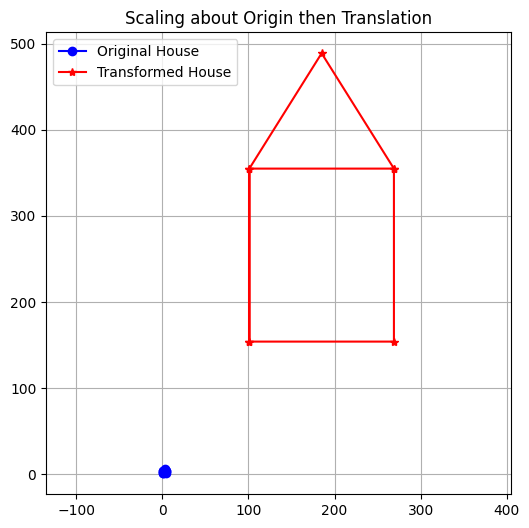

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# House: square base + triangle roof
def get_house_shape():
    # Format: [x, y, 1] (homogeneous coordinates)
    house = np.array([
        [1, 1, 1],  # bottom-left
        [4, 1, 1],  # bottom-right
        [4, 4, 1],  # top-right
        [1, 4, 1],  # top-left
        [1, 1, 1],  # close base
        [1, 4, 1],  # left roof base
        [2.5, 6, 1],  # roof peak
        [4, 4, 1]   # right roof base
    ])
    return house

# Generic transformation application
def transform_object(points, transformation_matrix):
    return np.dot(points, transformation_matrix.T)

# Translation matrix
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

# Scaling matrix
def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

# Scaling about arbitrary point (px, py)
def scaling_about_point(sx, sy, px, py):
    T1 = translation_matrix(-px, -py)
    S = scaling_matrix(sx, sy)
    T2 = translation_matrix(px, py)
    return T2 @ S @ T1  # Combined transformation

# Plotting function
def plot_figure(original, transformed, title):
    plt.figure(figsize=(6, 6))
    plt.plot(original[:, 0], original[:, 1], 'bo-', label='Original House')
    plt.plot(transformed[:, 0], transformed[:, 1], 'r*-', label='Transformed House')
    plt.title(title)
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

# --- Main Execution ---
house = get_house_shape()

print("Choose operation:")
print("a. Scaling about origin followed by translation")
print("b. Scaling with reference to an arbitrary point")
choice = input("Enter choice (a/b): ").strip().lower()

if choice == 'a':
    sx = float(input("Enter scaling factor in X: "))
    sy = float(input("Enter scaling factor in Y: "))
    tx = float(input("Enter translation in X: "))
    ty = float(input("Enter translation in Y: "))

    scale_matrix = scaling_matrix(sx, sy)
    translate_matrix = translation_matrix(tx, ty)
    combined_matrix = translate_matrix @ scale_matrix

    transformed = transform_object(house, combined_matrix)
    plot_figure(house, transformed, f"Scaling about Origin then Translation")

elif choice == 'b':
    sx = float(input("Enter scaling factor in X: "))
    sy = float(input("Enter scaling factor in Y: "))
    px = float(input("Enter reference point X: "))
    py = float(input("Enter reference point Y: "))

    combined_matrix = scaling_about_point(sx, sy, px, py)
    transformed = transform_object(house, combined_matrix)
    plot_figure(house, transformed, f"Scaling about Point ({px}, {py})")

else:
    print("Invalid choice. Please choose 'a' or 'b'.")
